In [1]:
import pandas as pd
from stock_data_analyser import *

In [7]:
sda= StockDataAnalyser(stock_symbol='MSFT')
sda.fetch_and_store_stock_data(mode='sql')

2025-04-16 10:23:11 - StockDataAnalyser - INFO - Fetching stock data for MSFT...
2025-04-16 10:23:11 - StockDataScraper - INFO - Fetching stock data for MSFT...
2025-04-16 10:23:14 - StockDataScraper - INFO - Fetched stock data for MSFT successfully...
2025-04-16 10:23:14 - StockDataAnalyser - INFO - Saved stock data to sql


,Open,High,Low,Close,Volume,EMA,Bollinger_Upper,Bollinger_Lower,Close_Lag1,Close_Lag2,...,Close_Lag12,Close_Lag13,Close_Lag14,Close_Lag15,Close_Lag16,Close_Lag17,Close_Lag18,Close_Lag19,Trend,Stock_name
2025-03-18,387.070,387.3700,381.1000,383.52,19486850,384.445883,405.269889,357.752111,388.70,388.56,...,396.99,392.53,399.73,397.90,404.00,408.21,416.13,414.77,NaN,MSFT
2025-03-17,386.700,392.7050,385.5700,388.70,22474272,384.851037,405.367339,357.743661,388.56,378.77,...,392.53,399.73,397.90,404.00,408.21,416.13,414.77,409.64,NaN,MSFT
2025-03-14,379.775,390.2300,379.5100,388.56,19952846,385.204272,405.379594,357.742406,378.77,383.27,...,399.73,397.90,404.00,408.21,416.13,414.77,409.64,408.43,NaN,MSFT
2025-03-13,383.155,385.3200,377.4500,378.77,20473017,384.591484,405.283330,357.580670,383.27,380.45,...,397.90,404.00,408.21,416.13,414.77,409.64,408.43,410.54,NaN,MSFT
2025-03-12,382.950,385.2165,378.9507,383.27,24253567,384.465628,404.560897,357.581103,380.45,380.16,...,404.00,408.21,416.13,414.77,409.64,408.43,410.54,409.04,NaN,MSFT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-29,255.460,256.1000,249.0000,252.51,40589023,249.525190,255.433368,239.927632,254.56,261.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT
2021-04-28,256.078,256.5399,252.9500,254.56,46903119,250.004696,256.014234,239.653766,261.97,261.55,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT
2021-04-27,261.585,263.1900,260.1200,261.97,31014213,251.144249,258.578796,238.114204,261.55,261.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT
2021-04-26,261.660,262.4350,260.1700,261.55,19763346,252.135273,260.672016,237.097984,261.15,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MSFT


In [8]:
df=sda.stock_data


In [4]:
# # df['Close_Lead1'] = df['Close'].shift(-10)
# for i in range(1,5):
#     df[f"Close_Lead{i}"] = df['Close'].shift(-i)
# df.dropna(inplace=True)


In [9]:
df.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'EMA', 'Bollinger_Upper',
       'Bollinger_Lower', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3',
       'Close_Lag4', 'Close_Lag5', 'Close_Lag6', 'Close_Lag7', 'Close_Lag8',
       'Close_Lag9', 'Close_Lag10', 'Close_Lag11', 'Close_Lag12',
       'Close_Lag13', 'Close_Lag14', 'Close_Lag15', 'Close_Lag16',
       'Close_Lag17', 'Close_Lag18', 'Close_Lag19', 'Trend', 'Stock_name'],
      dtype='object')

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow import keras
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


2025-04-16 10:24:27.159146: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-16 10:24:27.183049: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744779267.197729   33125 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744779267.202554   33125 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1744779267.215599   33125 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [15]:
# Drop non-numeric and target column from features
'''
        'Close_Lag1', 'Close_Lag2',
       'Close_Lag3', 'Close_Lag4', 'Close_Lag5', 'Close_Lag6', 'Close_Lag7',
       'Close_Lag8', 'Close_Lag9', 'Close_Lag10', 'Close_Lag11', 'Close_Lag12',
       'Close_Lag13', 'Close_Lag14', 'Close_Lag15', 'Close_Lag16',
       'Close_Lag17', 'Close_Lag18', 'Close_Lag19', 
'''

# Define input (X) and target (y)
y = df['Close'].values  # Target variable
X = df.drop(columns=['Open', 'High', 'Low', 'Volume', 'EMA','Close', 'Bollinger_Upper','Bollinger_Lower', 'Trend', 'Stock_name']).values  # Features


In [16]:
y.shape, X.shape


((980,), (980, 19))

In [35]:

# Normalize features
scalerX = StandardScaler()
scalerY = StandardScaler()
# X = scalerX.fit_transform(X)
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
# X_train = scalerX.fit_transform(X_train)
# X_test = scalerX.transform(X_test)
# y_train = scalerY.fit_transform(y_train.reshape(-1, 1))
# y_test = scalerY.transform(y_test.reshape(-1, 1))
# xtrain_scaled = scalerX.fit_transform(X_train)
# xtest_scaled = scalerX.transform(X_test)


In [36]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, type(X_train)

((784, 19), (196, 19), (784,), (196,), numpy.ndarray)

In [61]:
# # Define the neural network model
model = keras.Sequential([
    # keras.layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),  
    keras.layers.LSTM(256, return_sequences=True, input_shape=(X.shape[1],)),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Output layer for regression (no activation)
])
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense

# model = Sequential()
# model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
# model.add(LSTM(50, return_sequences=True))
# model.add(LSTM(50))
# model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

# from tensorflow.keras.optimizers import Adam
# model.compile(optimizer=Adam(learning_rate=1e-3), loss='mse', metrics=['mae'])


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Increase epochs
EPOCHS = 100

# Train the model with callbacks
model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[ checkpoint]
)


# Evaluate the model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.2f}")

ValueError: Input 0 of layer "lstm_9" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 19)

In [43]:
import matplotlib.pyplot as plt

# Get predictions
# y_train_pred = scalerY.inverse_transform(model.predict(X_train))
# y_test_pred = scalerY.inverse_transform(model.predict(X_test))
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)
y_train = y_train
y_test = y_test



25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [44]:
X_train

array([[421.9 , 427.93, 423.26, ..., 425.23, 421.41, 417.32],
       [318.27, 314.98, 314.27, ..., 319.91, 323.8 , 324.9 ],
       [377.43, 377.85, 373.07, ..., 346.07, 338.11, 337.31],
       ...,
       [319.97, 327.  , 322.46, ..., 327.5 , 336.34, 335.92],
       [259.53, 254.25, 256.72, ..., 267.7 , 258.86, 253.13],
       [334.  , 333.13, 329.37, ..., 292.88, 294.23, 294.85]])

In [49]:
y_train_pred

array([[333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60345],
       [333.60345],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],
       [333.60342],


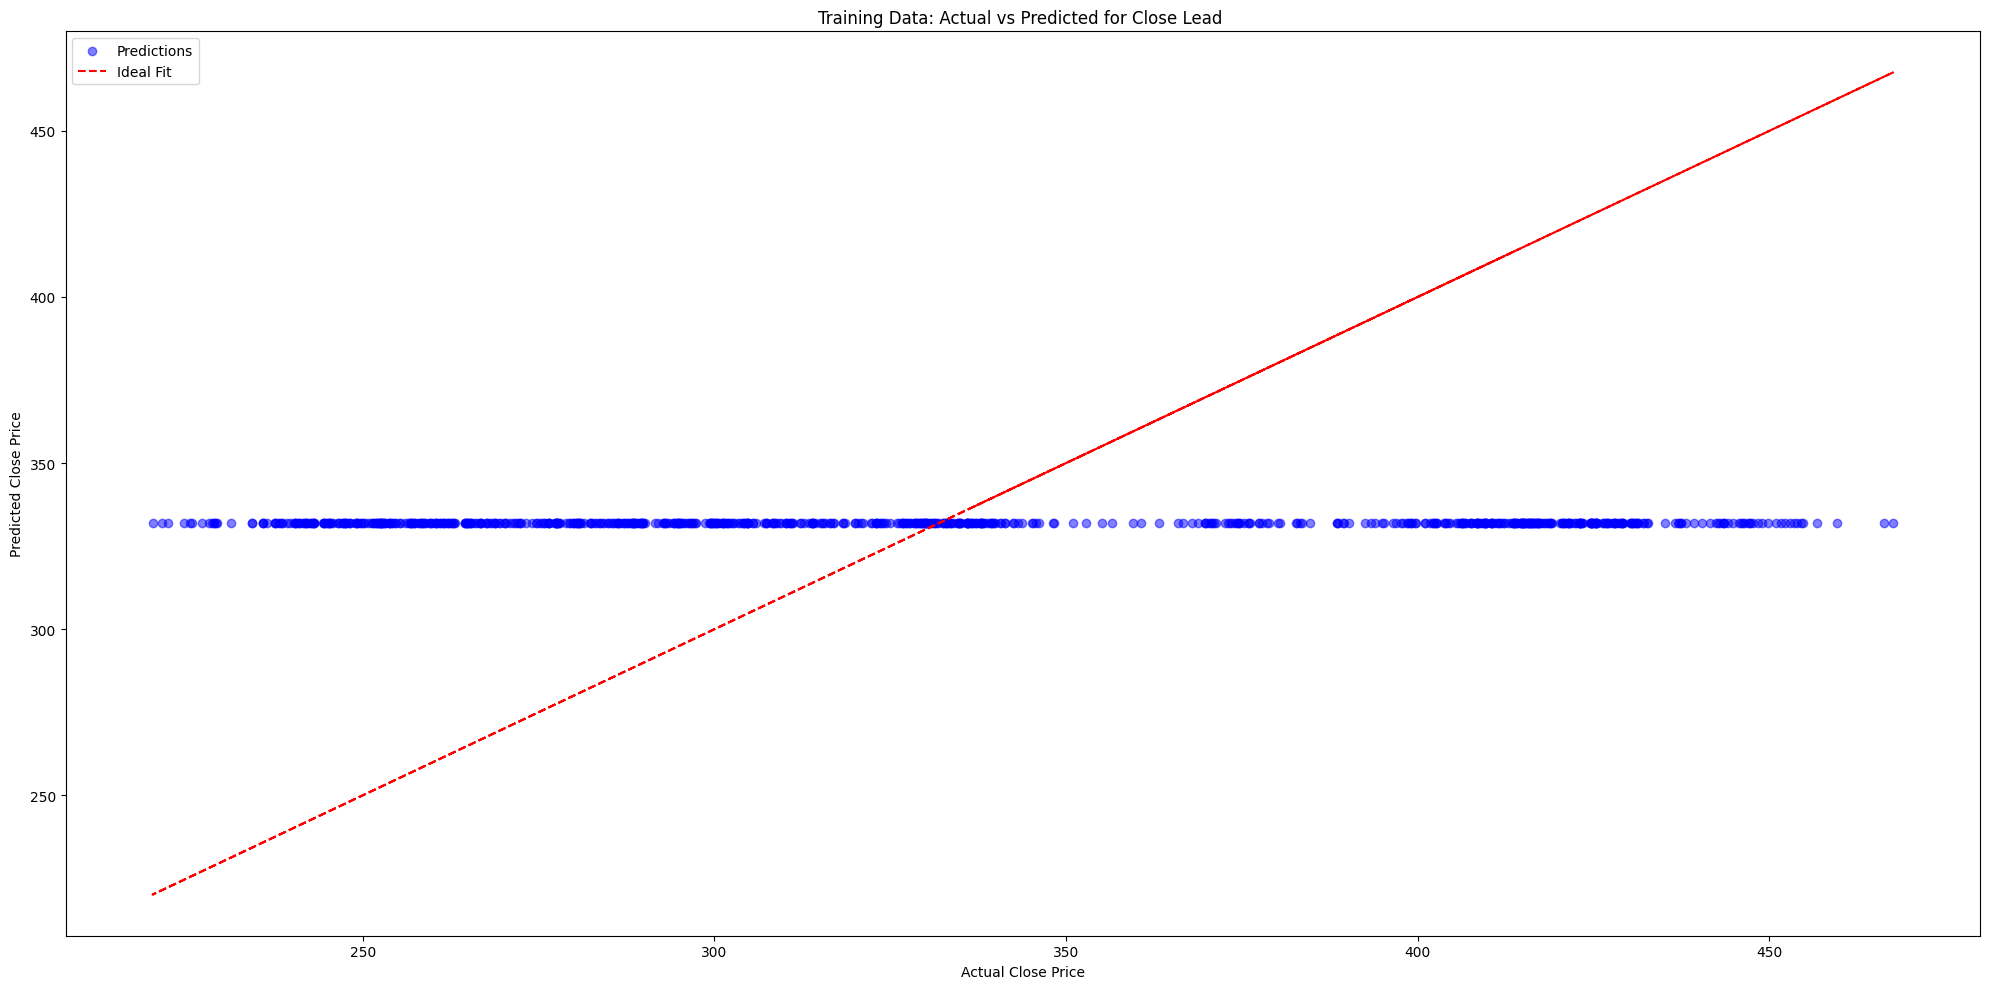

In [26]:
plt.figure(figsize=(20,10))
# for i in range(1,5):
# plt.subplot(2,2,i)
# scalerY.inverse_transform(y_train)
# plt.scatter(scalerY.inverse_transform(y_train), y_train_pred, alpha=0.5, color='blue', label="Predictions")
# plt.plot(scalerY.inverse_transform(y_train), scalerY.inverse_transform(y_train), color='red', linestyle='dashed', label="Ideal Fit")
plt.scatter(scalerY.inverse_transform(y_train), y_train_pred, alpha=0.5, color='blue', label="Predictions")
plt.plot(scalerY.inverse_transform(y_train), scalerY.inverse_transform(y_train), color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title(f"Training Data: Actual vs Predicted for Close Lead ")
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
len(y_test)

196

In [15]:
y_test1=scalerY.inverse_transform(y_test)
y_test1.shape

(196, 4)

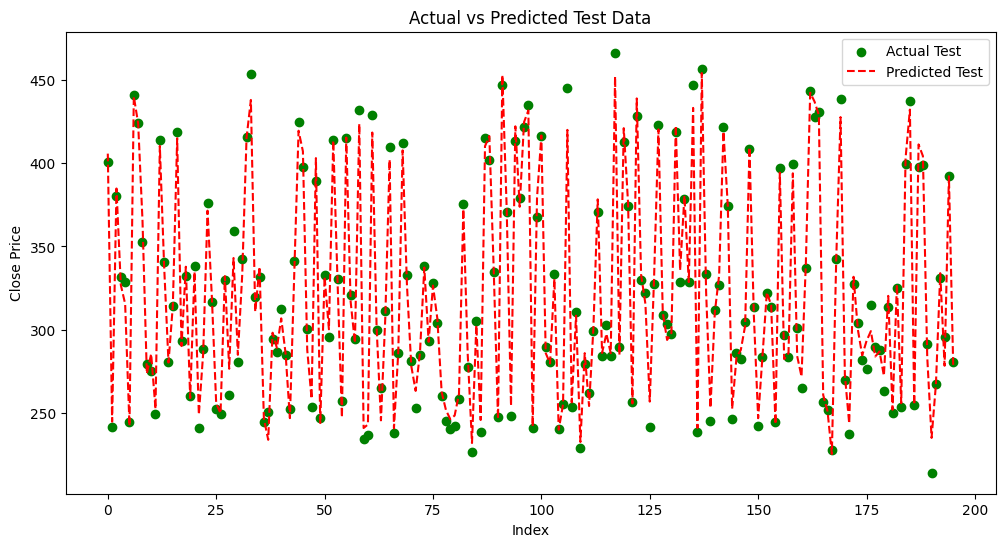

In [16]:
# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
plt.scatter(range(0,  len(y_test)), scalerY.inverse_transform(y_test)[:,0], label="Actual Test", color='green', linewidth=1)
plt.plot(range(0,  len(y_test)), y_test_pred[:,0], label="Predicted Test", color='red', linestyle='dashed')
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Test Data")
plt.legend()
plt.show()

In [17]:
X.shape

(980, 18)

(784, 18) (784, 4)
Test MAE: 0.12


ValueError: x and y must be the same size

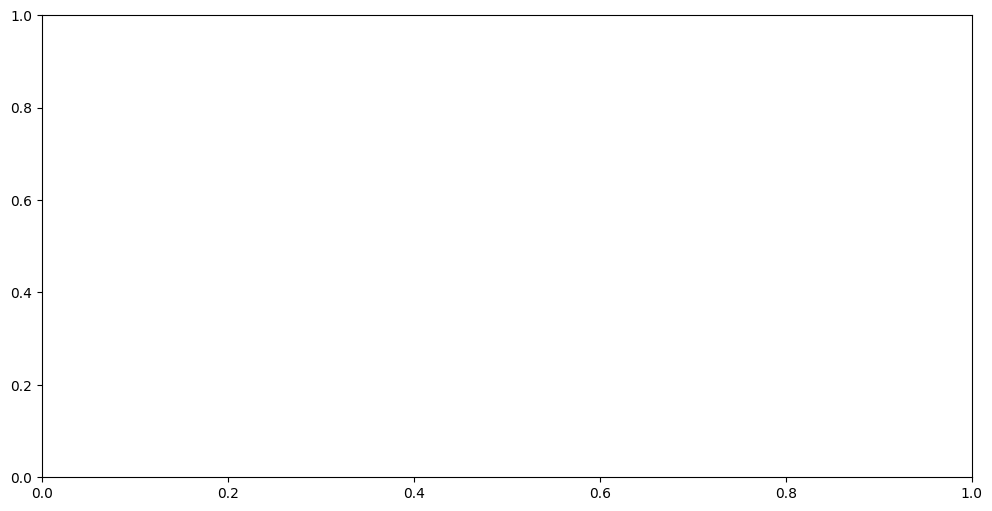

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error
# Define Bagging Regressor with Decision Trees
bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(),  # Use 'estimator' instead of 'base_estimator'
    n_estimators=1,  
    max_samples=0.2,  
    bootstrap=True,   
    random_state=42
)
print(X_train.shape, y_train.shape)
# Train the model
bagging_model.fit(X_train, y_train)

# Get predictions
y_train_pred = bagging_model.predict(X_train)
y_test_pred = bagging_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_test_pred)
print(f"Test MAE: {mae:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 6))
# plt.plot(range(len(y_train)), y_train, label="Actual Train", color='blue', linewidth=1)
# plt.plot(range(len(y_train)), y_train_pred, label="Predicted Train", color='cyan', linestyle='dashed')

plt.scatter(range(len(y_train), len(y_train) + len(y_test)), y_test, label="Actual Test", color='green', linewidth=1)
plt.plot(range(len(y_train), len(y_train) + len(y_test)), y_test_pred, label="Predicted Test", color='red', linestyle='dashed')

plt.xlabel("Time Index")
plt.ylabel("Close Price")
plt.title("Bagging Model: Stock Close Price Prediction")
plt.legend()
plt.show()
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='blue', label="Predictions")
plt.plot(y_train, y_train, color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Training Data: Actual vs Predicted")
plt.legend()

# Plot Testing Data
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='green', label="Predictions")
plt.plot(y_test, y_test, color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Close Price")
plt.ylabel("Predicted Close Price")
plt.title("Testing Data: Actual vs Predicted")
plt.legend()

plt.tight_layout()
plt.show()

In [1]:
import warnings
warnings.filterwarnings("ignore")


In [5]:
from NNmodel import StockPriceNN
regressor = StockPriceNN(stock_symbol="AAPL", endpoint='localhost:6000')
regressor.preprocess()
# regressor.load_model()



In [6]:
regressor.train(epochs=200)

(764, 19)
19
(192, 19)
(192, 1)
Epoch 1/200
20/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3344 - mae: 0.4267
Epoch 1: val_loss improved from inf to 0.04616, saving model to models/AAPL_best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.3025 - mae: 0.4020 - val_loss: 0.0462 - val_mae: 0.1745
Epoch 2/200
14/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0801 - mae: 0.2168 
Epoch 2: val_loss improved from 0.04616 to 0.02010, saving model to models/AAPL_best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0761 - mae: 0.2100 - val_loss: 0.0201 - val_mae: 0.1134
Epoch 3/200
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0519 - mae: 0.1663
Epoch 3: val_loss did not improve from 0.02010
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0518 - mae: 0.1665 - val_loss: 0.0255 - val_mae: 0.1172
Epoch 4/200
18/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0372 - mae: 0.1447
Epoch 4: val_loss improved from 0.02010 to 0.01682, saving model to models/AAPL_best_model.k

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0085 - mae: 0.0726 
Test MAE: 0.07
Test Loss: 0.01
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


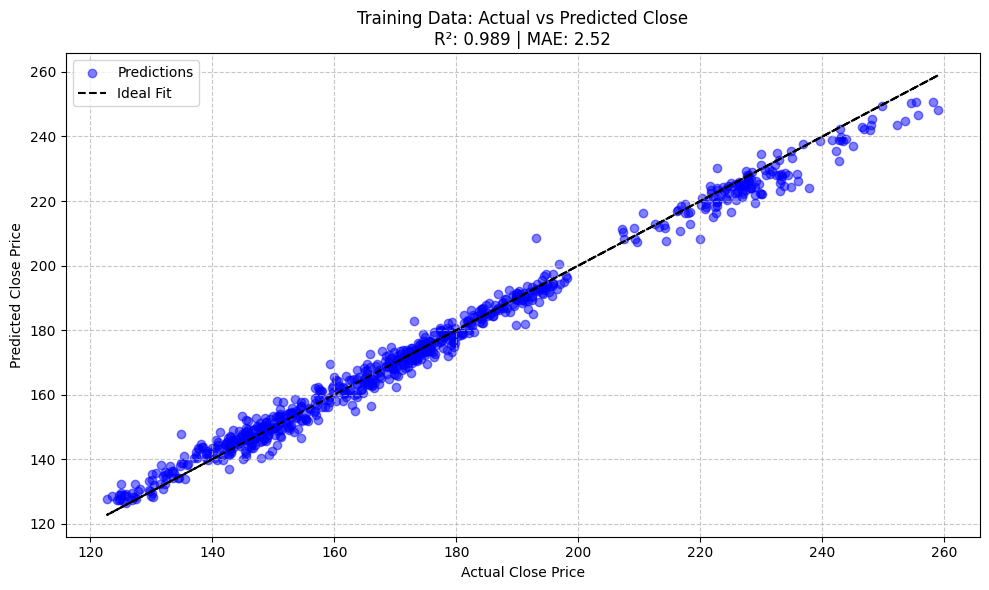

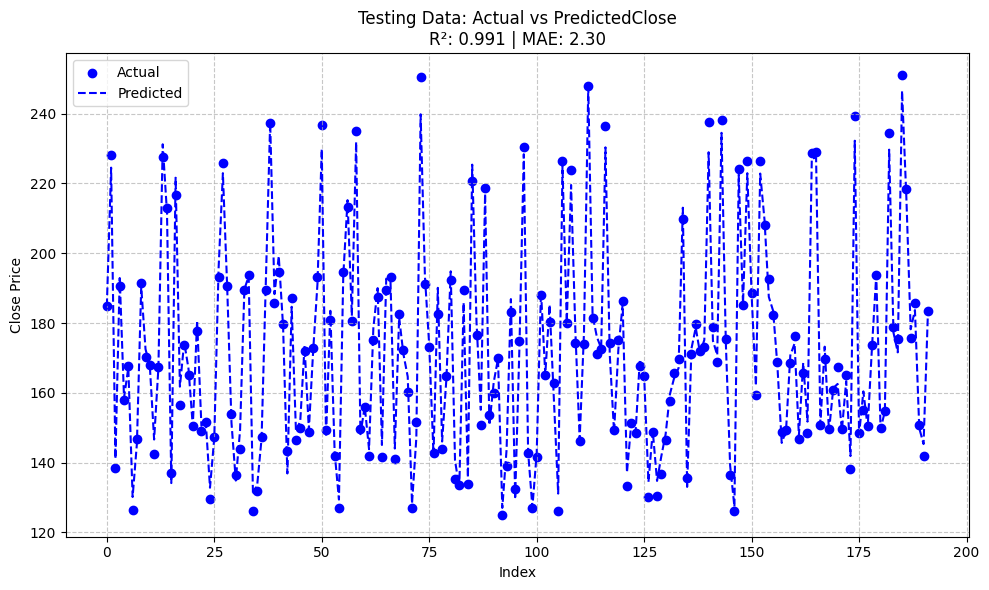

In [7]:

regressor.evaluate()
regressor.plot_predictions()

In [1]:
from NNmodel import StockPriceNN
regressor = StockPriceNN(stock_symbol="MSFT")
model=regressor.load_model()

2025-05-16 19:05:06.066233: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-16 19:05:06.077535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747402506.092695   12623 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747402506.096525   12623 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747402506.108460   12623 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TypeError: StockPriceNN.__init__() missing 1 required positional argument: 'endpoint'

In [ ]:
scalerX.inverse_transform(X_test)

array([[409.06, 399.04, 406.32, ..., 423.08, 420.99, 420.21],
       [241.22, 242.05, 245.03, ..., 252.51, 256.92, 257.22],
       [378.77, 388.56, 388.7 , ..., 373.11, 359.84, 357.86],
       ...,
       [278.91, 275.85, 288.5 , ..., 310.7 , 315.41, 313.86],
       [388.49, 388.61, 401.02, ..., 393.08, 395.16, 389.97],
       [274.82, 282.47, 283.65, ..., 276.44, 275.79, 278.85]])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


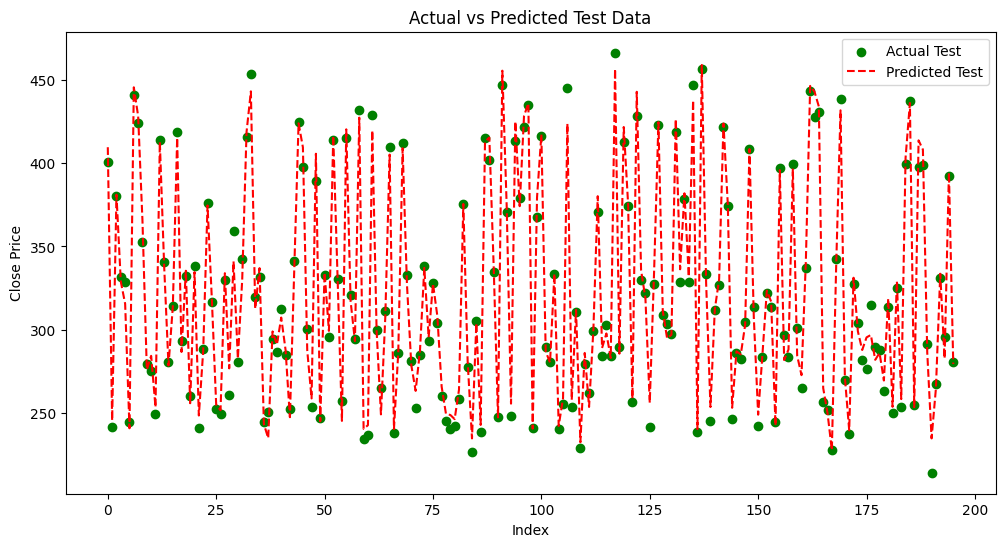

In [27]:
y_test_pred=regressor.predict(scalerX.inverse_transform(X_test))
y_test=y_test
plt.figure(figsize=(12, 6))
plt.scatter(range(0,  len(y_test)), scalerY.inverse_transform(y_test)[:,0], label="Actual Test", color='green', linewidth=1)
plt.plot(range(0,  len(y_test)), y_test_pred[:,0], label="Predicted Test", color='red', linestyle='dashed')
plt.xlabel("Index")
plt.ylabel("Close Price")
plt.title("Actual vs Predicted Test Data")
plt.legend()
plt.show()

In [ ]:
y_train_pred = scalerY.inverse_transform(model.predict(X_train))
y_test_pred = scalerY.inverse_transform(model.predict(X_test))
y_train = y_train
y_test = y_test

In [5]:
import yfinance as yf
from custom_exceptions import *
from custom_logger import CustomLogger
import requests
import os
# load env
from dotenv import load_dotenv
load_dotenv()
import datetime
import pandas as pd
class StockDataScraper:
    """
    Class for scraping stock data from internet
    """
    def __init__(self, stockSymbol):
        self.stock_symbol = stockSymbol
        timestamp = datetime.datetime.now().strftime("%Y%m%d")
        self.logger = CustomLogger("StockDataScraper", log_file=f'./Logs/stock_data_scraper/{timestamp}.log').get_logger()

        self.stock_data= None
        self.structured_stock_data= None
    
    def dumpIntoCSV(self):
        try: 
            df = pd.DataFrame.from_dict(self.stock_data['Time Series (Daily)'], orient='index')

            df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

            # only save upto 1200 rows
            df = df.iloc[:1000]
            # Convert the columns to numeric
            df = df.apply(pd.to_numeric) 
            self.structured_stock_data = df

            csv_path = os.path.join(os.getcwd(), 'stock_data', f'{self.stock_symbol}_data.csv')
            # Check if the directory exists, if not create it
            os.makedirs(os.path.dirname(csv_path), exist_ok=True)
            # Save the DataFrame to a CSV file
            df.to_csv(csv_path)

            self.logger.info(f"Data dumped into {csv_path} successfully...")
        except Exception as e:
            self.logger.error(f"Failed to dump data into CSV: {e}")
            raise CustomException(f"Failed to dump data into CSV: {e}")
    def getStockData(self, period='5y'):
        try:
            try:
                # print("entering")
                self.logger.info(f"Fetching stock data for {self.stock_symbol}...")
                
                # Yfinance is not working for some stocks, so we need to use Alpha Vantage
                # historical_data= self.yahoo_finance_data(period=period)

                # ALPHAVANTAGE API
                alpha_data = self.alpha_vantage_data()
                historical_data=pd.DataFrame.from_dict(self.stock_data['Time Series (Daily)'], orient='index')
                historical_data.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
                historical_data=historical_data.iloc[:1000].apply(pd.to_numeric)
                # print(historical_data.size)
            except Exception as e:
                raise_custom_exception(ScraperError, message=f"Failed to fetch data for {self.stock_symbol}: {e}")

            # used with yfinance ONLY
            # historical_data.drop(['Dividends', 'Stock Splits'], axis=1, inplace=True)
            
            self.logger.info(f"Fetched stock data for {self.stock_symbol} successfully...")
            
            return historical_data
        except CustomException as e:
            self.logger.error(f"A custom error occurred StockDataScraper->getStockData: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred StockDataScraper->getStockData: {e}")
            return None
        
    def getStockInfo(self):
        try:
            return self.yahoo_finance_info()
        except Exception as e:
            raise CustomException(f"Failed to fetch stock info for {self.stock_symbol}: {e}")
        
    def yahoo_finance_data(self, period='5y'):
        try:
            stock = yf.Ticker(self.stock_symbol)
            historical_data = stock.history(period=period)
            return historical_data
        except Exception as e:
            raise CustomException(f"Failed to fetch data for {self.stock_symbol}: {e}")

    def yahoo_finance_info(self):
        try:
            stock = yf.Ticker(self.stock_symbol)
            return stock.info
        except Exception as e:
            raise CustomException(f"Failed to fetch stock info for {self.stock_symbol}: {e}")

    def yahoo_finance_news(self, period='1d'):
        try:
            stock = yf.Ticker(self.stock_symbol)
            news = stock.news(period=period)
            return news
        except Exception as e:
            raise CustomException(f"Failed to fetch news for {self.stock_symbol}: {e}")

    def alpha_vantage_data(self):
        try:
            url=f"https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol={self.stock_symbol}&apikey={os.environ['ALPHA_VANTAGE_API_KEY']}&outputsize=full&datatype=json"
            response = requests.get(url)
            data = response.json()
            self.stock_data = data
            return data
        except Exception as e:
            raise CustomException(f"Failed to fetch data for {self.stock_symbol}: {e}")
        
    def alpha_vantage_info(self):
        try:
            url=f"https://www.alphavantage.co/query?function=OVERVIEW&symbol={self.stock_symbol}&apikey={os.environ['ALPHA_VANTAGE_API_KEY']}"
            response = requests.get(url)
            data = response.json()
            return data
        except Exception as e:
            raise CustomException(f"Failed to fetch stock info for {self.stock_symbol}: {e}")

    def alpha_vantage_news(self):
        try:
            url=f"https://www.alphavantage.co/query?function=TIME_SERIES_INTRADAY&symbol={self.stock_symbol}&interval=5min&apikey={os.environ['ALPHA_VANTAGE_API_KEY']}"
            response = requests.get(url)
            data = response.json()
            return data
        except Exception as e:
            raise CustomException(f"Failed to fetch news for {self.stock_symbol}: {e}")
        

In [6]:
from minio import Minio
from minio.error import S3Error
import os
import logging

class MinIOHandler:
    def __init__(self, endpoint, access_key, secret_key, bucket_name, secure=False):
        self.endpoint = endpoint
        self.access_key = access_key
        self.secret_key = secret_key
        self.bucket_name = bucket_name
        self.secure = secure

        self.logger = logging.getLogger(__name__)
        self.client = Minio(
            endpoint=self.endpoint,
            access_key=self.access_key,
            secret_key=self.secret_key,
            secure=self.secure
        )

        self._ensure_bucket()

    def _ensure_bucket(self):
        """Ensure the bucket exists."""
        if not self.client.bucket_exists(self.bucket_name):
            self.client.make_bucket(self.bucket_name)
            self.logger.info(f"🪣 Created bucket: {self.bucket_name}")
        else:
            self.logger.info(f"🪣 Bucket '{self.bucket_name}' already exists.")

    def upload_file(self, file_path, object_name=None, content_type="application/octet-stream"):
        """Upload a file to MinIO."""
        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"File not found: {file_path}")

        object_name = object_name or os.path.basename(file_path)

        try:
            self.client.fput_object(
                bucket_name=self.bucket_name,
                object_name=object_name,
                file_path=file_path,
                content_type=content_type
            )
            self.logger.info(f"✅ Uploaded '{file_path}' as '{object_name}' to bucket '{self.bucket_name}'")
        except S3Error as e:
            self.logger.error(f"❌ S3 Error during upload: {e}")
            raise e

    def download_file(self, object_name, destination_path):
        """Download a file from MinIO."""
        try:
            self.client.fget_object(
                bucket_name=self.bucket_name,
                object_name=object_name,
                file_path=destination_path
            )
            self.logger.info(f"✅ Downloaded '{object_name}' to '{destination_path}'")
        except S3Error as e:
            self.logger.error(f"❌ S3 Error during download: {e}")
            raise e
    
    def delete_file_from_minio(self, object_name):
        try:
            self.client.remove_object(self.bucket_name, object_name)
            self.logger.info(f"✅ Deleted '{object_name}' from bucket '{self.bucket_name}'")
        except S3Error as e:
            self.logger.error(f"❌ S3 Error during deletion: {e}")
            raise e
    
    def delete_file_from_local(self, file_path):
        try:
            os.remove(file_path)
            self.logger.info(f"✅ Deleted '{file_path}' from local")
        except FileNotFoundError:
            self.logger.warning(f"❌ File '{file_path}' not found on local")


In [1]:
import autokeras as ak

2025-05-21 13:51:06.649494: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-21 13:51:06.659570: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747815666.672000   52915 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747815666.675256   52915 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747815666.683929   52915 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import pandas as pd
from custom_exceptions import *
import datetime
from dotenv import load_dotenv
import joblib
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt
load_dotenv(override=True)
class StockPriceNN:
    def __init__(self, stock_symbol, endpoint):
        self.sda= StockDataAnalyser(stock_symbol=stock_symbol)
        self.df=None
        # self.df = df.copy()
        self.model = None
        self.scalerX = StandardScaler()
        self.scalerY = StandardScaler()
        self.stock_symbol = stock_symbol
        timestamp = datetime.datetime.now().strftime("%Y%m%d")
        self.minio_handler=MinIOHandler(
            # endpoint=os.getenv("MINIO_ENDPOINT"),
            endpoint=endpoint,
            access_key=os.getenv("MINIO_ACCESS_KEY"),
            secret_key=os.getenv("MINIO_SECRET_KEY"),
            bucket_name=os.getenv("MINIO_BUCKET_NAME"),
            secure=False
        )
        self.logger = CustomLogger("StockPriceNN", log_file=f'./Logs/stock_price_nn/{timestamp}.log').get_logger()
        

    def preprocess(self):
        try:
        # data=self.sda.fetch_and_store_stock_data(mode='sql')
            self.df=self.sda.fetch_from_db()
            # print(self.df.head())
            y = self.df[['High', 'Low']].values
            X = self.df.drop(columns=['Open', 'High', 'Low', 'Volume', 'EMA','Close',
                                    'Bollinger_Upper', 'Close_Lag1', 'Bollinger_Lower',
                                    'Trend', 'Stock_name', 'index']).values
            # print(y)
            print(X)
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
            
            self.X_train = self.scalerX.fit_transform(X_train)
            self.X_test = self.scalerX.transform(X_test)
            self.y_train = self.scalerY.fit_transform(y_train)
            self.y_test = self.scalerY.transform(y_test)
            joblib.dump(self.scalerX, f'scalers/scalerX_{self.stock_symbol}.pkl')
            joblib.dump(self.scalerY, f'scalers/scalerY_{self.stock_symbol}.pkl')
            self.minio_handler.upload_file(file_path=f'scalers/scalerX_{self.stock_symbol}.pkl', object_name=f'scalers/scalerX_{self.stock_symbol}.pkl')
            self.minio_handler.upload_file(file_path=f'scalers/scalerY_{self.stock_symbol}.pkl', object_name=f'scalers/scalerY_{self.stock_symbol}.pkl')
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockPriceNN->preprocess: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockPriceNN->preprocess: {e}")
            return None

    def predict(self, x_input):
        try:
            x_input = self.scalerX.transform(x_input)
            return self.scalerY.inverse_transform(self.model.predict(x_input))
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockPriceNN->predict: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockPriceNN->predict: {e}")
            return None

    def build_model(self, input_dim):
        try:
            print(input_dim)
            
            self.model = keras.Sequential([
                keras.layers.Dense(256, activation='relu', input_shape=(input_dim,)),
                keras.layers.Dropout(0.1),
                keras.layers.Dense(128, activation='relu'),
                keras.layers.Dropout(0.2),
                keras.layers.Dense(64, activation='relu'),
                keras.layers.Dropout(0.1),
                keras.layers.Dense(32, activation='relu'),
                keras.layers.Dense(2)
            ])
            self.model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockPriceNN->build_model: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockPriceNN->build_model: {e}")
            return None

    def load_model(self):
        try:
            # self.minio_handler.download_file(object_name=f'{self.stock_symbol}_best_model.keras', destination_path=f'models/{self.stock_symbol}_best_model.keras')
            self.minio_handler.download_file(object_name=f'scalers/scalerX_{self.stock_symbol}.pkl', destination_path=f'scalers/scalerX_{self.stock_symbol}.pkl')
            self.minio_handler.download_file(object_name=f'scalers/scalerY_{self.stock_symbol}.pkl', destination_path=f'scalers/scalerY_{self.stock_symbol}.pkl')
            self.model = keras.models.load_model(f'models/{self.stock_symbol}_best_model.keras')
            self.scalerX = joblib.load(f'scalers/scalerX_{self.stock_symbol}.pkl')
            self.scalerY = joblib.load(f'scalers/scalerY_{self.stock_symbol}.pkl')
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockPriceNN->load_model: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockPriceNN->load_model: {e}")
            return None
    

    def train(self, epochs=200):
        try:
            early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True, verbose=1)
            checkpoint = ModelCheckpoint(filepath=f'models/{self.stock_symbol}_best_model.keras', monitor='val_loss', save_best_only=True, verbose=1)
            print(self.X_train.shape)
            self.build_model(input_dim=self.X_train.shape[1])
            print(self.X_test.shape)
            print(self.y_test.shape)
            self.model.fit(
                self.X_train, self.y_train,
                epochs=epochs,
                batch_size=32,
                validation_data=(self.X_test, self.y_test),
                callbacks=[early_stop, checkpoint]
            )
            print("reached")
            self.minio_handler.upload_file(file_path=f'models/{self.stock_symbol}_best_model.keras', object_name=f'models/{self.stock_symbol}_best_model.keras')
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockPriceNN->train: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockPriceNN->train: {e}")
            return None

    def evaluate(self):
        try:
            loss, mae = self.model.evaluate(self.X_test, self.y_test)
            print(f"Test MAE: {mae:.2f}")
            print(f"Test Loss: {loss:.2f}")
            return mae
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockPriceNN->evaluate: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockPriceNN->evaluate: {e}")
            return None


    def plot_predictions(self):
        try:
            y_train_pred = self.scalerY.inverse_transform(self.model.predict(self.X_train))
            y_test_pred = self.scalerY.inverse_transform(self.model.predict(self.X_test))
            y_train_actual = self.scalerY.inverse_transform(self.y_train)
            y_test_actual = self.scalerY.inverse_transform(self.y_test)

            target_names = ["High", "Low"]
            color_map = ["blue", "green"]

            def plot_scatter_fit(y_true, y_pred, title, feature_idx, color):
                r2 = r2_score(y_true[:, feature_idx], y_pred[:, feature_idx])
                mae = mean_absolute_error(y_true[:, feature_idx], y_pred[:, feature_idx])

                plt.figure(figsize=(10, 6))
                plt.scatter(y_true[:, feature_idx], y_pred[:, feature_idx], alpha=0.5, color=color, label="Predictions")
                plt.plot(y_true[:, feature_idx], y_true[:, feature_idx], color='black', linestyle='dashed', label="Ideal Fit")
                plt.xlabel(f"Actual {target_names[feature_idx]} Price")
                plt.ylabel(f"Predicted {target_names[feature_idx]} Price")
                plt.title(f"{title}\nR²: {r2:.3f} | MAE: {mae:.2f}")
                plt.grid(True, linestyle='--', alpha=0.7)
                plt.legend()
                plt.tight_layout()
                plt.show()

            def plot_line_vs_index(y_true, y_pred, title, feature_idx, color):
                r2 = r2_score(y_true[:, feature_idx], y_pred[:, feature_idx])
                mae = mean_absolute_error(y_true[:, feature_idx], y_pred[:, feature_idx])

                plt.figure(figsize=(10, 6))
                plt.scatter(range(len(y_true)), y_true[:, feature_idx], label="Actual", color='blue')
                # plt.scatter(y_true[:, feature_idx], label="Actual", color='green')
                plt.plot(range(len(y_pred)),y_pred[:, feature_idx], label="Predicted", color=color, linestyle='--')
                plt.xlabel("Index")
                plt.ylabel(f"{target_names[feature_idx]} Price")
                plt.title(f"{title}\nR²: {r2:.3f} | MAE: {mae:.2f}")
                plt.grid(True, linestyle='--', alpha=0.7)
                plt.legend()
                plt.tight_layout()
                plt.show()

            # Plot Training Scatter
            for i in range(y_train_actual.shape[1]):
                plot_scatter_fit(y_train_actual, y_train_pred, f"Training Data: Actual vs Predicted {target_names[i]}", i, color_map[i])

            # Plot Testing Line
            for i in range(y_test_actual.shape[1]):
                plot_line_vs_index(y_test_actual, y_test_pred, "Testing Data: Actual vs Predicted" + target_names[i], i, color_map[i])

        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockPriceNN->plot_predictions: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockPriceNN->plot_predictions: {e}")
            return None



In [8]:
import requests
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from custom_logger import CustomLogger
import datetime
from custom_exceptions import raise_custom_exception, ScraperError, CustomException

import requests
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from custom_logger import CustomLogger
import datetime
from custom_exceptions import raise_custom_exception, ScraperError, CustomException
import plotly.graph_objects as go
from sqlalchemy import create_engine, text
from dotenv import load_dotenv
load_dotenv()
class StockDataAnalyser:
    """
    Class for analysing stock data
    """
    def __init__(self, stock_symbol):
        self.stock_symbol: str = stock_symbol
        timestamp = datetime.datetime.now().strftime("%Y%m%d")
        self.logger = CustomLogger("StockDataAnalyser", log_file=f'./Logs/stock_data_analyser/{timestamp}.log').get_logger()
        self.stock_data=None

    def fetch_from_db(self):
        try:
            self._fetch_from_sql()
            return self.stock_data
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockDataAnalayser->fetch_from_db: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockDataAnalayser->fetch_from_db: {e}")
            return None 
        
    def fetch_from_db_and_analyze(self):
        try:
            self._fetch_from_sql()
            self.plot_stock_data(self.stock_data)
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockDataAnalayser->fetch_from_sql_and_analyze: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockDataAnalayser->fetch_from_sql_and_analyze: {e}")
            return None        

    def fetch_and_store_stock_data(self, mode='csv'):
        try:
            
            self.logger.info(f"Fetching stock data for {self.stock_symbol}...")
            
            try:
                scraper = StockDataScraper(stockSymbol=self.stock_symbol)
                historical_data = scraper.getStockData()
            except Exception as e:
                raise_custom_exception(ScraperError, message=f"Failed to create StockDataScraper object for {self.stock_symbol}: {e}")

            historical_data = self._get_bollinger_bands(historical_data)
            
            for i in range(1, 20):
                historical_data[f'Close_Lag{i}'] = historical_data['Close'].shift(-i)
            
            historical_data.drop(historical_data.head(20).index, inplace=True)
            historical_data['Trend']=self.getSeasonalDecomposition(historical_data)
            historical_data['Stock_name']=self.stock_symbol
            
            self.stock_data = historical_data
            
            if mode=='sql':
                self._dump_into_sql()
                self.logger.info(f"Saved stock data to sql")
            else:
                historical_data.to_csv(f'./stock_data/{self.stock_symbol}_data.csv')
                self.logger.info(f"Saved stock data to CSV file: {self.stock_symbol}_data.csv")
            
            # For dev purposes only
            # historical_data.to_csv(f'./stock_data/{self.stock_symbol}_data.csv')
            # self.logger.info(f"Saved stock data to CSV file: {self.stock_symbol}_data.csv")
            
            return historical_data
        
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockDataAnalayser->fetch_and_plot_stock_data: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockDataAnalayser->fetch_and_plot_stock_data: {e}")
            return None

    def fetch_and_plot_stock_data(self):
        try:
            
            self.logger.info(f"Fetching stock data for {self.stock_symbol}...")
            
            try:
                scraper = StockDataScraper(stockSymbol=self.stock_symbol)
                historical_data = scraper.getStockData()
            except Exception as e:
                raise_custom_exception(ScraperError, message=f"Failed to create StockDataScraper object for {self.stock_symbol}: {e}")

            historical_data = self._get_bollinger_bands(historical_data)
            
            for i in range(1, 20):
                historical_data[f'Close_Lag{i}'] = historical_data['Close'].shift(i)
            
            historical_data.drop(historical_data.head(20).index, inplace=True)
            historical_data['Trend']=self.getSeasonalDecomposition(historical_data)
            historical_data['Stock_name']=self.stock_symbol
            historical_data['index'] = historical_data.index
            self.plot_stock_data(historical_data)
            self.stock_data = historical_data
            
            
            return historical_data
        
        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockDataAnalayser->fetch_and_plot_stock_data: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockDataAnalayser->fetch_and_plot_stock_data: {e}")
            return None

    def _fetch_from_sql(self):
        try:
            db_url = os.getenv('POSTGRES_URI')

            # Create SQLAlchemy engine
            engine = create_engine(db_url)
            # print(f"SELECT * FROM {self.stock_symbol.lower()}")
            df=pd.read_sql(f"SELECT * FROM {self.stock_symbol.lower()}", engine)
            if df.empty:
                df=self.fetch_and_store_stock_data(mode='sql')
            # print(df)
            # df.index=df['']
            df=df.dropna(axis=0)
            self.stock_data=df
            print(df.tail())

        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockDataAnalayser->_fetch_from_sql: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockDataAnalayser->_fetch_from_sql: {e}")
            return None

    def _dump_into_sql(self):
        try:
            db_url = os.getenv('POSTGRES_URI')

            # Create SQLAlchemy engine
            engine = create_engine(db_url)
            with engine.connect() as connection:
                result = connection.execute(
                    text(f"SELECT to_regclass('public.{self.stock_symbol.lower()}')")
                ).scalar()
                
                if result:  # If table exists
                    connection.execute(text(f"DELETE FROM public.{self.stock_symbol.lower()}"))
                    connection.commit()

            
            self.stock_data.to_sql(self.stock_symbol.lower(),engine, if_exists="replace", index=True)

        except CustomException as e:
            self.logger.error(f"A custom error occurred at StockDataAnalayser->dump_into_sql: {e}")
            return None
        except Exception as e:
            self.logger.error(f"An error occurred at StockDataAnalayser->dump_into_sql: {e}")
            return None


    def getSeasonalDecomposition(self, stock_data):
        """
        Perform seasonal decomposition on stock data.
        """
        result = seasonal_decompose(stock_data['Close'], model='additive', period=25)
        return result.trend
    
    

    def _get_bollinger_bands(self,data, bollinger_window=20, short_window=20):
        """
        Calculate Bollinger Bands for a given stock data.
        """
        rolling_mean = data['Close'].rolling(window=bollinger_window).mean()
        rolling_std = data['Close'].rolling(window=bollinger_window).std()
        data['EMA'] = data['Close'].ewm(span=short_window, adjust=False).mean()
        data['Bollinger_Upper'] = rolling_mean + (2 * rolling_std)
        data['Bollinger_Lower'] = rolling_mean - (2 * rolling_std)
        return data

    def plot_stock_data(self, data):
        """
        Plot stock data with Bollinger Bands.
        """
        fig = go.Figure()

        # Add Close Price line
        fig.add_trace(go.Scatter(x=data['index'], y=data['Close'], mode='lines', name='Close Price', line=dict(color='blue')))

        # Add Bollinger Upper Band
        fig.add_trace(go.Scatter(x=data['index'], y=data['Bollinger_Upper'], mode='lines', name='Bollinger Upper Band', line=dict(color='red')))

        # Add Bollinger Lower Band
        fig.add_trace(go.Scatter(x=data['index'], y=data['Bollinger_Lower'], mode='lines', name='Bollinger Lower Band', line=dict(color='green')))

        # Add seasonal decomposition components
        fig.add_trace(go.Scatter(x=data['index'], y=data['EMA'], mode='lines', name='EMA', line=dict(color='orange')))
        # Customize layout
        fig.update_layout(
            title="Stock Price with Bollinger Bands",
            xaxis_title="Date",
            yaxis_title="Price",
            legend=dict(x=0, y=1),
            # xaxis=dict(rangeslider=dict(visible=True))  # Enables zooming and panning
        )

        # Show the figure
        fig.show()

In [9]:

regressor = StockPriceNN(stock_symbol="MSFT", endpoint='localhost:6000')
regressor.preprocess()
# regressor.load_model()



          index     Open    High     Low   Close    Volume         EMA  \
956  2021-05-26  251.430  252.94  250.75  251.49  17771600  255.692343   
957  2021-05-25  251.769  252.75  250.82  251.72  17704303  255.314024   
958  2021-05-24  247.785  251.16  247.51  250.78  21411547  254.882213   
959  2021-05-21  247.565  248.33  244.74  245.17  21863058  253.957240   
960  2021-05-20  243.960  247.95  243.86  246.48  21800716  253.245122   

     Bollinger_Upper  Bollinger_Lower  Close_Lag1  ...  Close_Lag12  \
956       267.311390       243.304110      251.72  ...       247.18   
957       265.763203       243.496797      250.78  ...       252.46   
958       263.886692       243.900308      245.17  ...       249.73   
959       262.849393       243.191607      246.48  ...       246.47   
960       262.129997       242.616003      243.12  ...       247.79   

     Close_Lag13  Close_Lag14  Close_Lag15  Close_Lag16  Close_Lag17  \
956       252.46       249.73       246.47       247.79 

In [13]:
df=regressor.df
X=df.drop(columns=['Open', 'High', 'Low', 'Volume', 'EMA','Close', 'Bollinger_Upper','Bollinger_Lower', 'Trend', 'Stock_name']).values
y=df['Close'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)


In [ ]:
regressor = ak.

AttributeError: 'numpy.ndarray' object has no attribute 'fit'

In [10]:
regressor.train(epochs=10)

(759, 18)
18
(190, 18)
(190, 2)
Epoch 1/10


/home/steeldev/Desktop/Github/PotatoTrade/mlenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


 1/24 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - loss: 1.0455 - mae: 0.8954
Epoch 1: val_loss improved from inf to 0.05729, saving model to models/MSFT_best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4382 - mae: 0.5038 - val_loss: 0.0573 - val_mae: 0.1899
Epoch 2/10
 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0735 - mae: 0.2091
Epoch 2: val_loss improved from 0.05729 to 0.02958, saving model to models/MSFT_best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0731 - mae: 0.2098 - val_loss: 0.0296 - val_mae: 0.1373
Epoch 3/10
 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0735 - mae: 0.1997
Epoch 3: val_loss improved from 0.02958 to 0.01779, saving model to models/MSFT_best_model.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0534 - mae: 0.1772 - val_loss: 0.0178 - val_mae: 0.1069
Epoch 4/10
 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0316 - mae: 0.1272
Epoch 4: val_loss did not improve from 0.01779
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - l

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0137 - mae: 0.0904 
Test MAE: 0.09
Test Loss: 0.01
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


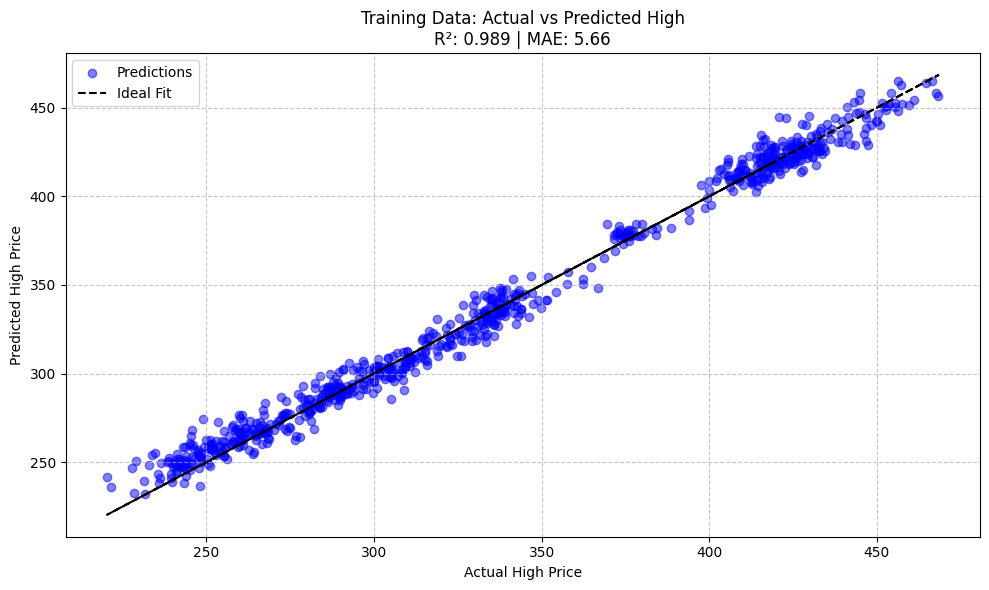

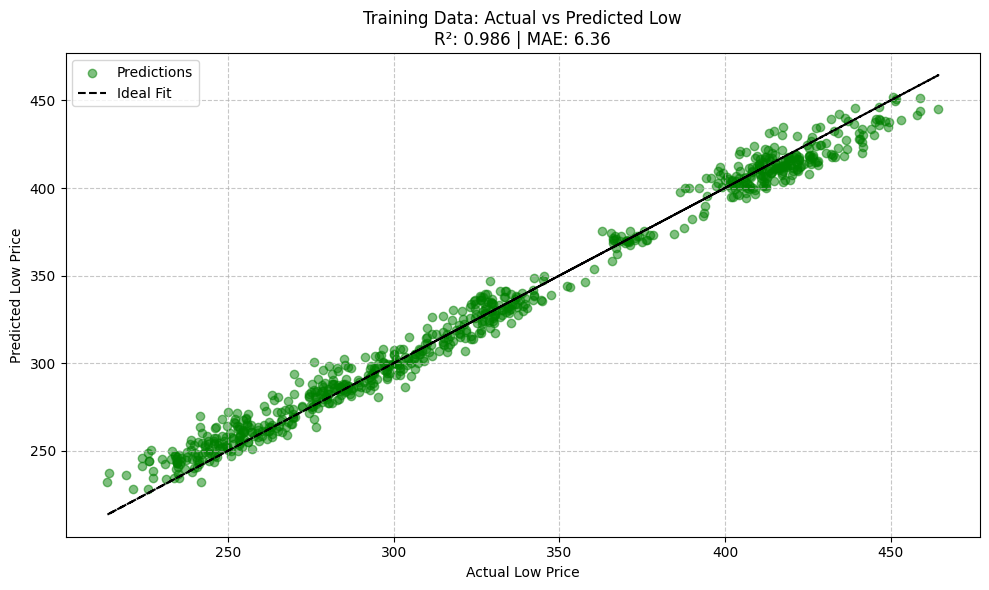

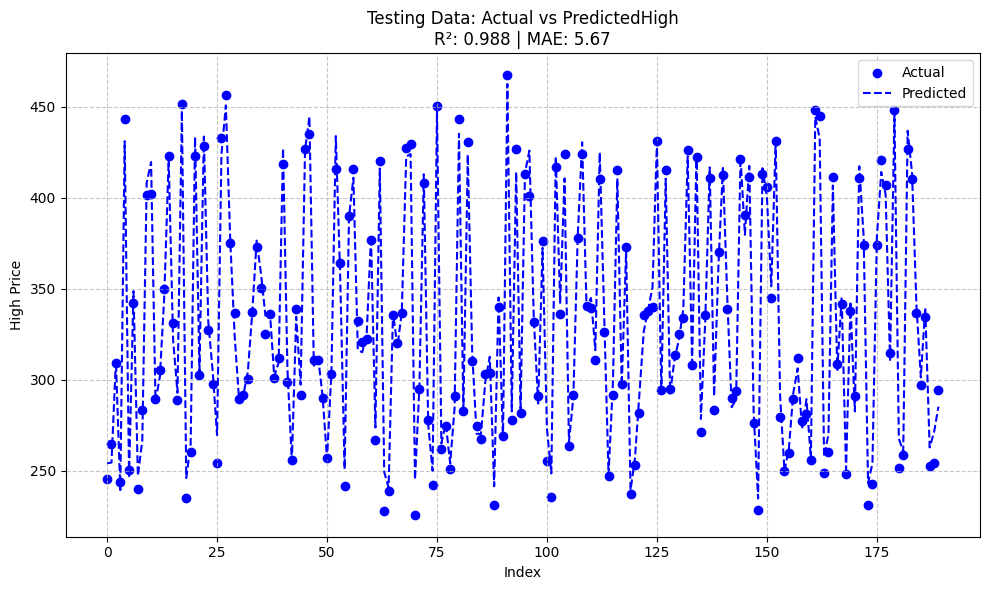

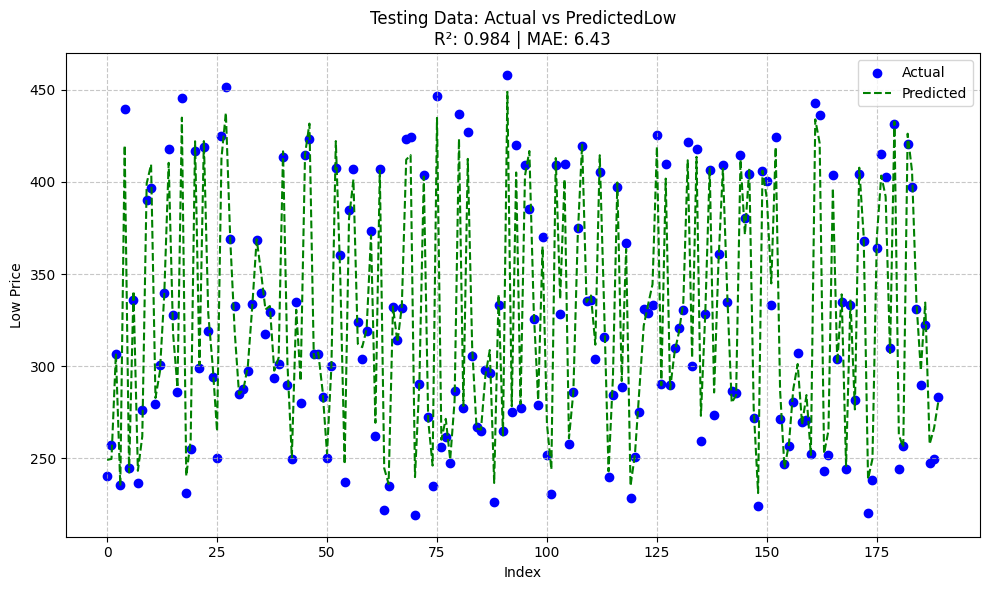

In [11]:

regressor.evaluate()
regressor.plot_predictions()